### 验证时间管理能力 计算能力 能不能在长期阶段影响ELO

In [1]:
import pandas as pd
import json
import ast
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit
from tqdm import tqdm
from tqdm.auto import tqdm
tqdm.pandas()
import os
import math
import psutil
import gc
import chess
import chess.engine
import chess.svg
from IPython.display import display, HTML
import subprocess
import time
from pathlib import Path
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as patches
import sqlite3
from matplotlib.patches import ConnectionPatch, Rectangle

db_path = r"C:\sqlite3\chess.db"
table = 'games'

In [2]:
conn = sqlite3.connect(db_path)
df = pd.read_sql(f'SELECT uid, Date, White, Black, WhiteElo, BlackElo FROM {table}', conn)
df.head()

,uid,Date,White,Black,WhiteElo,BlackElo
0,1,2025.04.01,Petra Kejzar,Daniel Barria,2177,2637
1,2,2025.04.01,Nataliya Buksa,Jorge Carlos Antonio,2639,2195
2,3,2025.04.01,Hubert Zieba,Nikolaos Skiadopoulos,2607,2049
3,4,2025.04.01,Karina Ambartsumova,Nino Maisuradze,2709,2358
4,5,2025.04.01,Alexander Donchenko,Andriy Diachek,2835,2494


In [3]:
# 将games表转为选手时间序列
# 1. 提取白方数据
white_players = df[['White', 'Date', 'WhiteElo']].rename(
    columns={'White': 'Player', 'Date': 'Date', 'WhiteElo': 'ELO'}
)
# 2. 提取黑方数据
black_players = df[['Black', 'Date', 'BlackElo']].rename(
    columns={'Black': 'Player', 'Date': 'Date', 'BlackElo': 'ELO'}
)

# 3. 合并并转为日期格式
player_history = pd.concat([white_players, black_players])
player_history['Date'] = pd.to_datetime(player_history['Date'])
player_history.head()

,Player,Date,ELO
0,Petra Kejzar,2025-04-01,2177
1,Nataliya Buksa,2025-04-01,2639
2,Hubert Zieba,2025-04-01,2607
3,Karina Ambartsumova,2025-04-01,2709
4,Alexander Donchenko,2025-04-01,2835


In [4]:
player_history.shape

(2035416, 3)

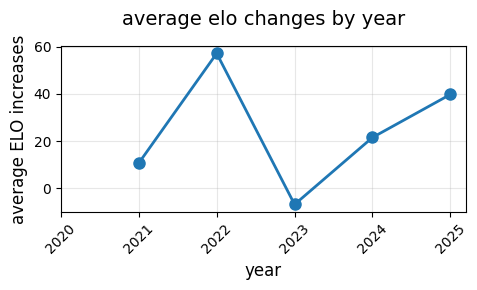

每年平均ELO：
   Year      ELO  ELO_Growth
0  2020  2472.53         NaN
1  2021  2483.19       10.67
2  2022  2540.36       57.17
3  2023  2533.49       -6.87
4  2024  2555.01       21.52
5  2025  2594.77       39.77


In [5]:
# 处理日期，提取年份
player_history['Date'] = pd.to_datetime(player_history['Date'])  # 转成日期格式
player_history['Year'] = player_history['Date'].dt.year  # 提取年份
# 按年份计算【所有选手的平均ELO】
yearly_avg_elo = player_history.groupby('Year')['ELO'].mean().reset_index()
# 计算每年的ELO增幅
yearly_avg_elo['ELO_Growth'] = yearly_avg_elo['ELO'].diff()
plt.figure(figsize=(5, 3))
plt.plot(
    yearly_avg_elo['Year'], 
    yearly_avg_elo['ELO_Growth'], 
    marker='o', 
    linewidth=2, 
    markersize=8, 
    color='#1f77b4'
)
plt.title('average elo changes by year', fontsize=14, pad=15)
plt.xlabel('year', fontsize=12)
plt.ylabel('average ELO increases', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(yearly_avg_elo['Year'], rotation=45)  # 年份不重叠
plt.tight_layout()
plt.show()

print("每年平均ELO：")
print(yearly_avg_elo[['Year', 'ELO', 'ELO_Growth']].round(2))

<Axes: >

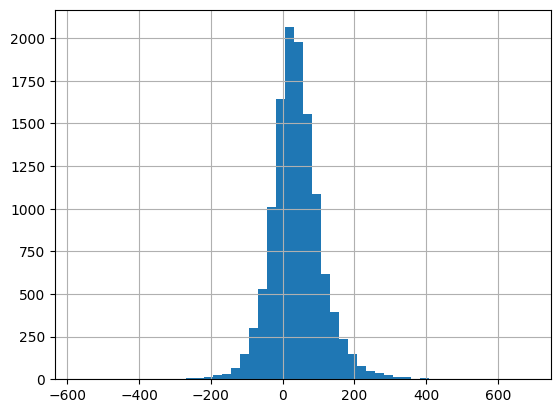

In [6]:
# 筛选出至少跨越3年的选手
valid_players = (
    player_history.groupby('Player')['Year'].nunique()
    .loc[lambda x: x >= 3]
    .index
)

# 2. 统计每个选手每年的平均 ELO 和 参赛场次
# 这里直接生成年度统计表
player_year = (
    player_history[player_history['Player'].isin(valid_players)]
    .groupby(['Player', 'Year'])
    .agg(
        mean_ELO=('ELO', 'mean'),
        game_count=('ELO', 'count')
    )
    .reset_index()
)

# 只保留一年内至少下过 5 场（或更多）的记录
# 这样算的平均分才不容易因为某一场的输赢产生巨大偏差
player_year = player_year[player_year['game_count'] >= 5]

# 算增长率
# 注意：因为过滤了场次，有些年份可能断开了，shift(-1) 依然有效，但需确保是时间顺序
player_year = player_year.sort_values(['Player', 'Year'])
player_year['ELO_next'] = player_year.groupby('Player')['mean_ELO'].shift(-1)
player_year['ELO_growth'] = player_year['ELO_next'] - player_year['mean_ELO']
player_year['ELO_growth'].hist(bins=50)

## rolling temporal prediction（滚动时间预测）
#### features_t  →  ELO_growth_{t→t+1}

### 先确定观察的选手有谁，要比赛多的

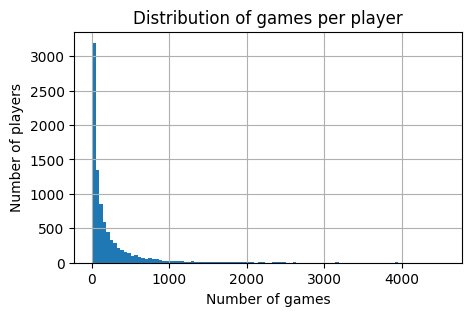

In [7]:
player_history['Player'] = player_history['Player'].str.lower().str.strip()
player_counts = (player_history.groupby('Player').size().reset_index(name='game_count'))
plt.figure(figsize=(5,3))
player_counts['game_count'].hist(bins=100)
plt.xlabel('Number of games')
plt.ylabel('Number of players')
plt.title('Distribution of games per player')
plt.show()

In [8]:
# 看不同分位数的人都总共比过多少场
print(player_counts['game_count'].quantile([0.5, 0.75, 0.8, 0.9, 0.95, 1.00]))
# 看比赛总数超过200的人有多少
threshold = 200
active_players = player_counts[player_counts['game_count'] >= threshold]['Player']
print(len(active_players))

0.50      86.0
0.75     249.0
0.80     322.0
0.90     588.4
0.95     953.0
1.00    4551.0
Name: game_count, dtype: float64
2659


In [9]:
active_player_history = player_history[player_history['Player'].isin(active_players)]
active_player_history.shape

(1659334, 4)

In [10]:
df_moves = pd.read_parquet(r'..\df_moves6.parquet')

elo_order = ['>=3000',  '2800-3000', '2600-2800', '2400-2600', '2200-2400',  '2000-2200', '<2000']
distinct_palette = sns.color_palette("viridis", len(elo_order))
color_map = dict(zip(elo_order, distinct_palette))

active_set = set(active_players)
# df_moves里的人名也转成小写
df_moves_active = df_moves[df_moves['Player'].str.lower().isin(active_set)].copy()
df_moves_active['Player'] = df_moves_active['Player'].str.lower()
print(f"原始行数: {len(df_moves)}")
print(f"过滤后行数: {len(df_moves_active)}")
print(f"保留比例: {len(df_moves_active) / len(df_moves):.2%}")
print(f"过滤后唯一选手数: {df_moves_active['Player'].nunique()}")

原始行数: 88912034
过滤后行数: 72915259
保留比例: 82.01%
过滤后唯一选手数: 2659


In [11]:
del df_moves
gc.collect()

8287

In [12]:
df_moves_active.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'Is_check',
       'Is_checkmate', 'Result', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'D', 'Cog_Speed'],
      dtype='object')

In [13]:
# 1. 只取 games 表中必要的两列，并确保 uid 类型与 df_moves_active 一致
# 假设你的 games 表变量名就叫 games_df
df = df[['uid', 'Date']].drop_duplicates('uid')

# 2. 合并到 df_moves_active
# how='left' 保证不改变 df_moves_active 的行数
df_moves_active = df_moves_active.merge(df, on='uid', how='left')

# 3. 转换 Date 为年份（既然你要做年度滚动预测）
# 假设 Date 是 '2025.04.01' 这种格式
df_moves_active['Year'] = df_moves_active['Date'].str.split('.').str[0].astype(int)

# 验证一下
print(df_moves_active[['uid', 'Date', 'Year']].head())

   uid        Date  Year
0   34  2025.04.01  2025
1   34  2025.04.01  2025
2   34  2025.04.01  2025
3   34  2025.04.01  2025
4   34  2025.04.01  2025


In [14]:
df_moves_active.columns

Index(['uid', 'Move_Idx', 'Player', 'Color', 'E', 'E1', 'E2', 'E3', 'E4', 'E5',
       'Judgment_Raw', 'Is_Error', 'Is_Blunder', 'Δi', 'Δ', 'ELO', 'ELO_Group',
       'Is_Forced', 'Is_Optimal', 'Remain_Time', 'Time_Group', 'Move_Time',
       'Game_Length', 'Progress', 'Relative_Stage(temp)', 'Is_check',
       'Is_checkmate', 'Result', 'P_model', 'S', 'P_model(Global=10.0cp)',
       'S(Global=10.0cp)', 'P_model(Global=50.0cp)', 'S(Global=50.0cp)',
       'P_model(Global=100.0cp)', 'S(Global=100.0cp)',
       'P_model(Global=150.0cp)', 'S(Global=150.0cp)', 'D', 'Cog_Speed',
       'Date', 'Year'],
      dtype='object')

In [15]:
df.head()

,uid,Date
0,1,2025.04.01
1,2,2025.04.01
2,3,2025.04.01
3,4,2025.04.01
4,5,2025.04.01


In [16]:
player_history.head()

,Player,Date,ELO,Year
0,petra kejzar,2025-04-01,2177,2025
1,nataliya buksa,2025-04-01,2639,2025
2,hubert zieba,2025-04-01,2607,2025
3,karina ambartsumova,2025-04-01,2709,2025
4,alexander donchenko,2025-04-01,2835,2025


#### active_player_elo放了活跃选手的年平均elo值

In [17]:
active_player_elo = (
    player_history[player_history['Player'].isin(active_set)]
    .groupby(['Player', 'Year'])['ELO']
    .mean()
    .reset_index()
)
active_player_elo.columns = ['Player', 'Year', 'mean_ELO']
active_player_elo.head()

,Player,Year,mean_ELO
0,4empechement,2021,2447.413223
1,4empechement,2022,2441.512605
2,4empechement,2023,2515.727273
3,aadit bhatia,2022,2447.375000
4,aadit bhatia,2023,2399.857988


In [18]:
active_player_elo['Player'].nunique()

2659

In [19]:
active_player_elo.shape

(11376, 3)

#### player_year_features放了活跃选手每年很多指标的均值

In [20]:
# 1. 确保参与计算的列都是数值型
cols_to_fix = ['Is_Optimal', 'Δi', 'Is_Blunder', 'Is_Error', 'Move_Time', 'Cog_Speed']
for col in cols_to_fix:
    df_moves_active[col] = pd.to_numeric(df_moves_active[col], errors='coerce')

# 把正负无穷全部替换为 NaN,不然只要认知速度有一个样本是inf，最后求出来这个选手这一年的那条数据对应的列就是inf
df_moves_active[cols_to_fix] = df_moves_active[cols_to_fix].replace([np.inf, -np.inf], np.nan)

# 2. 聚合计算（Pandas mean 默认就不计入 NaN）
player_year_features = df_moves_active.groupby(['Player', 'Year']).agg({
    'Is_Optimal': 'mean',
    'Δi': 'mean',
    'Is_Blunder': 'mean',
    'Is_Error': 'mean',
    'Move_Time': 'mean',
    'Cog_Speed': 'mean',
    'uid': 'count' # 顺便算一下这一年他贡献了多少步，方便后续过滤
}).rename(columns={'uid': 'move_count'}).reset_index()

# 3. 清理掉那些所有指标全是 NaN 的行
# 如果 move_count 为 0，说明这个选手那一年根本没数据
player_year_features = player_year_features.dropna(subset=cols_to_fix, how='all')

In [21]:
player_year_features.shape

(11368, 9)

In [22]:
player_year_features.head()

,Player,Year,Is_Optimal,Δi,Is_Blunder,Is_Error,Move_Time,Cog_Speed,move_count
0,4empechement,2021,0.538309,117.072052,0.038904,0.075228,4.896189,0.451630,5038
1,4empechement,2022,0.537192,80.296738,0.029833,0.059666,4.833811,0.454821,5028
2,4empechement,2023,0.502646,158.275131,0.031746,0.058201,5.718254,0.524378,378
3,aadit bhatia,2022,0.508280,235.066238,0.035669,0.080255,3.877962,1.136285,785
4,aadit bhatia,2023,0.529791,199.340256,0.041217,0.074863,4.331712,0.823947,7133


### 合并当前年份特征与当前年的elo均值

In [23]:
# 确保两个表的名字都已经是小写，方便匹配
player_year_features['Player'] = player_year_features['Player'].str.lower()
active_player_elo['Player'] = active_player_elo['Player'].str.lower()

# 合并：这一步让每一行都拥有了该选手“当年的表现”和“当年的平均分”
player_year_features = player_year_features.merge(
    active_player_elo[['Player', 'Year', 'mean_ELO']], 
    on=['Player', 'Year'], 
    how='inner'
)
player_year_features.shape

(11368, 10)

### 把每个选手后一年的elo均值也加进去

In [24]:
# 1. 必须先按选手和年份排序，否则 shift 后的数据就是乱的
player_year_features = player_year_features.sort_values(['Player', 'Year'])

# 2. 按选手分组，取下一年的 ELO 均值
# shift(-1) 的意思就是把下一行的值挪到当前行
player_year_features['next_year_ELO'] = player_year_features.groupby('Player')['mean_ELO'].shift(-1)

### 目标预测列：elo差值

In [25]:
# 3. 计算 Target
player_year_features['Target'] = player_year_features['next_year_ELO'] - player_year_features['mean_ELO']

# 4. 剔除每个选手的最后一年（因为 next_year_ELO 为空）
# 同时也自动处理了年份不连续的情况（比如一个选手 2022 年打了，2024 年才打，
# 那么 2022 年的 next_year_ELO 实际上是 2024 年的，中间跨度太大，建议检查年份连续性）
# player_year_features = player_year_features.dropna(subset=['Target'])

# 【可选】严谨起见，确保 next_year_ELO 确实是来自紧接着的下一年
# 如果一个选手 2022 年后直接跳到了 2024 年，这种样本可能需要剔除
player_year_features['Year_Gap'] = player_year_features.groupby('Player')['Year'].shift(-1) - player_year_features['Year']
player_year_features = player_year_features[(player_year_features['Year_Gap'] == 1) | (player_year_features['Year_Gap'].isna())].copy()

print(f"最终建模数据集行数: {len(player_year_features)}")

最终建模数据集行数: 10967


player_year_features目前情况：

连续年份的行：Target 有值，Year_Gap 是 1，保留。

跳年年份的行：Target 逻辑错误，Year_Gap 大于 1，剔除。

每个选手的最后一年：Target 是 NaN，Year_Gap 是 NaN，保留。

In [26]:
player_year_features.head()

,Player,Year,Is_Optimal,Δi,Is_Blunder,Is_Error,Move_Time,Cog_Speed,move_count,mean_ELO,next_year_ELO,Target,Year_Gap
0,4empechement,2021,0.538309,117.072052,0.038904,0.075228,4.896189,0.451630,5038,2447.413223,2441.512605,-5.900618,1.0
1,4empechement,2022,0.537192,80.296738,0.029833,0.059666,4.833811,0.454821,5028,2441.512605,2515.727273,74.214668,1.0
2,4empechement,2023,0.502646,158.275131,0.031746,0.058201,5.718254,0.524378,378,2515.727273,NaN,NaN,NaN
3,aadit bhatia,2022,0.508280,235.066238,0.035669,0.080255,3.877962,1.136285,785,2447.375000,2399.857988,-47.517012,1.0
4,aadit bhatia,2023,0.529791,199.340256,0.041217,0.074863,4.331712,0.823947,7133,2399.857988,2472.008475,72.150486,1.0


## 跑回归  结果不咋样

In [27]:
# 切出一个没有 NaN 的干净样本
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

# 提取回归样本：剔除最后一年（Target为空）和跳年的行
model_data = player_year_features.dropna(subset=['Target']).copy()

# 定义自变量 (X) 和 因变量 (y)
# 核心特征 + 控制变量（当前的 mean_ELO）
feature_cols = ['Is_Optimal', 'Is_Blunder', 'Is_Error', 'Move_Time', 'Cog_Speed', 'mean_ELO']
X = model_data[feature_cols]
y = model_data['Target']

# 特征标准化
# 因为 Is_Optimal 是 0-1 之间，而 Δi 可能是几百，不标准化无法比较权重
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)

# 给常数项留位置（线性回归必须加 const）
X_scaled = sm.add_constant(X_scaled)

In [28]:
# 拟合模型
model = sm.OLS(y, X_scaled).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Target   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     50.87
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           8.98e-62
Time:                        20:34:11   Log-Likelihood:                -46362.
No. Observations:                8308   AIC:                         9.274e+04
Df Residuals:                    8301   BIC:                         9.279e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         37.4091      0.704     53.116      0.0

In [29]:
model_data.head()

,Player,Year,Is_Optimal,Δi,Is_Blunder,Is_Error,Move_Time,Cog_Speed,move_count,mean_ELO,next_year_ELO,Target,Year_Gap
0,4empechement,2021,0.538309,117.072052,0.038904,0.075228,4.896189,0.451630,5038,2447.413223,2441.512605,-5.900618,1.0
1,4empechement,2022,0.537192,80.296738,0.029833,0.059666,4.833811,0.454821,5028,2441.512605,2515.727273,74.214668,1.0
3,aadit bhatia,2022,0.508280,235.066238,0.035669,0.080255,3.877962,1.136285,785,2447.375000,2399.857988,-47.517012,1.0
4,aadit bhatia,2023,0.529791,199.340256,0.041217,0.074863,4.331712,0.823947,7133,2399.857988,2472.008475,72.150486,1.0
5,aadit bhatia,2024,0.547185,170.140472,0.036100,0.066117,4.235629,0.930029,5097,2472.008475,2503.821429,31.812954,1.0


## 打算换成一个分类问题

1. 3分类    

In [30]:
# 1. 定义标签
def label_three_class(target):
    if target > 15: return 2   # 上涨
    if target < -15: return 0  # 下跌
    return 1                   # 持平 (基准组)

model_data['Label_3'] = model_data['Target'].apply(label_three_class)

# 2. 跑多元逻辑回归 (Multinomial Logit)
# 我们以“持平(1)”作为基准组 (reference group)
mn_logit = sm.MNLogit(model_data['Label_3'], X_scaled)
result_3 = mn_logit.fit()

print("--- 三分类回归结果 ---")
print(result_3.summary())

Optimization terminated successfully.
         Current function value: 0.892173
         Iterations 5
--- 三分类回归结果 ---
                          MNLogit Regression Results                          
Dep. Variable:                Label_3   No. Observations:                 8308
Model:                        MNLogit   Df Residuals:                     8294
Method:                           MLE   Df Model:                           12
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                0.007790
Time:                        20:34:11   Log-Likelihood:                -7412.2
converged:                       True   LL-Null:                       -7470.4
Covariance Type:            nonrobust   LLR p-value:                 3.245e-19
 Label_3=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0816      0.037      2.191      0.028       0.009       0.155
Is_Optimal   

In [31]:
# 1. 定义标签：前 25% 为 1，其余为 0
threshold_high = model_data['Target'].quantile(0.75)
model_data['Is_Star'] = (model_data['Target'] > threshold_high).astype(int)

# 2. 跑逻辑回归 (Logistic Regression)
logit_star = sm.Logit(model_data['Is_Star'], X_scaled)
result_star = logit_star.fit()

# 3. 计算胜算比 (Odds Ratio) —— 论文里这个比系数更好听
odds_ratios = np.exp(result_star.params)

print("--- 潜力股识别结果 ---")
print(result_star.summary())
print("\n胜算比 (Odds Ratios):")
print(odds_ratios)

Optimization terminated successfully.
         Current function value: 0.546646
         Iterations 5
--- 潜力股识别结果 ---
                           Logit Regression Results                           
Dep. Variable:                Is_Star   No. Observations:                 8308
Model:                          Logit   Df Residuals:                     8301
Method:                           MLE   Df Model:                            6
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                 0.02790
Time:                        20:34:11   Log-Likelihood:                -4541.5
converged:                       True   LL-Null:                       -4671.9
Covariance Type:            nonrobust   LLR p-value:                 2.134e-53
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1401      0.026    -43.441      0.000      -1.192      -1.089
Is_Optimal   

In [32]:
from sklearn.metrics import roc_auc_score, classification_report

# 预测概率
probs = result_star.predict(X_scaled)
auc = roc_auc_score(model_data['Is_Star'], probs)

print(f"潜力识别模型的 AUC 值: {auc:.3f}")
# AUC > 0.5 说明比随机猜好，AUC > 0.65 在行为预测中就算很不错了

潜力识别模型的 AUC 值: 0.612


In [44]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. 获取预测概率 (0 到 1 之间)
# Logit 模型预测的是概率
y_prob = result_star.predict(X_scaled)

# 设定阈值转换成类别
# 因为你是取前 25% 作为 Is_Star，通常默认阈值是 0.5
# 但在不平衡数据中，也可以用 threshold_high 对应的概率作为切分点
y_pred = (y_prob > 0.2033).astype(int)
y_true = model_data['Is_Star']

# 3. 计算混淆矩阵四个核心指标
# ravel() 会将 2x2 矩阵展平为四个值
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print("--- 混淆矩阵 (Confusion Matrix) ---")
print(f"真阴性 (TN): {tn} - 预测不涨，实际也没涨")
print(f"假阳性 (FP): {fp} - 预测会涨，实际没怎么涨 (看走眼)")
print(f"假阴性 (FN): {fn} - 预测不涨，实际暴涨了 (漏掉天才)")
print(f"真阳性 (TP): {tp} - 预测会涨，实际真暴涨了 (抓到潜力股)")

# 4. 计算 AUC
auc_score = roc_auc_score(y_true, y_prob)

print(f"\nAUC 值: {auc_score:.4f}")
print("\n--- 详细分类报告 ---")
print(classification_report(y_true, y_pred))

--- 混淆矩阵 (Confusion Matrix) ---
真阴性 (TN): 1998 - 预测不涨，实际也没涨
假阳性 (FP): 4233 - 预测会涨，实际没怎么涨 (看走眼)
假阴性 (FN): 397 - 预测不涨，实际暴涨了 (漏掉天才)
真阳性 (TP): 1680 - 预测会涨，实际真暴涨了 (抓到潜力股)

AUC 值: 0.6118

--- 详细分类报告 ---
              precision    recall  f1-score   support

           0       0.83      0.32      0.46      6231
           1       0.28      0.81      0.42      2077

    accuracy                           0.44      8308
   macro avg       0.56      0.56      0.44      8308
weighted avg       0.70      0.44      0.45      8308



In [46]:
from sklearn.metrics import precision_recall_curve

# 1. 获取预测概率
y_prob = result_star.predict(X_scaled)
y_true = model_data['Is_Star']

# 2. 计算不同阈值下的 P 和 R
precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

# 3. 计算 F1-score 并找到最大值对应的阈值
# f1 = 2 * (p * r) / (p + r)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"最优阈值: {best_threshold:.4f}")
print(f"该阈值下的最大 F1-score: {f1_scores[best_idx]:.4f}")

# 4. 用最优阈值重新生成预测结果
y_pred_best = (y_prob > best_threshold).astype(int)
print("\n--- 最优阈值下的分类报告 ---")
print(classification_report(y_true, y_pred_best))

最优阈值: 0.2033
该阈值下的最大 F1-score: 0.4205

--- 最优阈值下的分类报告 ---
              precision    recall  f1-score   support

           0       0.83      0.32      0.46      6231
           1       0.28      0.81      0.42      2077

    accuracy                           0.44      8308
   macro avg       0.56      0.56      0.44      8308
weighted avg       0.70      0.44      0.45      8308



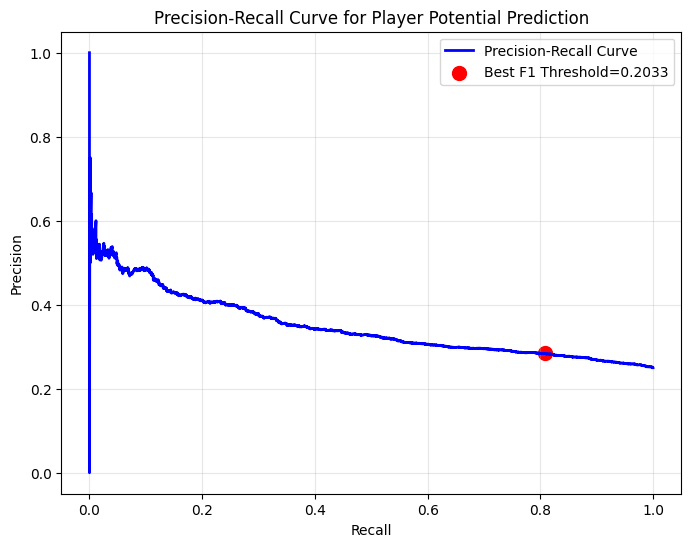

In [43]:
# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve', color='blue', lw=2)
plt.scatter(recall[best_idx], precision[best_idx], 
            color='red', s=100, label=f'Best F1 Threshold={best_threshold:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Player Potential Prediction')
plt.legend()
plt.grid(alpha=0.3)
plt.show()